# 4 Modelling

Notebook 01 built the canonical dataset and notebook 02 cleaned it. This notebook trains and
compares three gradient-boosting regressors on `cleaned_data.csv`, picks a winner on the test
split, explains it, and saves it.

**Three models, one skeleton.** LightGBM, XGBoost and CatBoost each get the same three
subsections (baseline cross-validation, tuning, final fit) followed by the same six metric
subsections. The bodies are short because the scoring and plotting helpers are written once and
reused.

**Every number in this notebook is in dollars.** Section 4.3 decides whether the models train on
raw `charges` or on `log1p(charges)`; whichever wins, predictions are converted back to dollars
before any metric is computed, so the tables always read as money.

**Runtime.** The CatBoost grid search in 4.8.2 takes two to three minutes. Everything else runs in
seconds.

## 4.1 Setup

Charts use plotly with the `notebook_connected` renderer, matching notebooks 01 and 02. The one
exception is the SHAP summary plot in 4.15, which only renders through matplotlib.

`PROJECT_ROOT` is resolved by walking up to the directory containing `pyproject.toml`, so the paths
hold regardless of the kernel's working directory.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import catboost as cb
import lightgbm as lgb
import xgboost as xgb
import shap
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from IPython.display import Markdown, display

# Load the plotly library from a CDN. Swap the lines below for offline use.
pio.renderers.default = "notebook_connected"
# pio.renderers.default = "notebook"

PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

TARGET = "charges"
CATEGORICAL_FEATURES = ["sex", "smoker", "region"]
# Needed only by the two scikit-learn models in 4.10 and 4.12, which cannot read
# a category column and must be handed one-hot numbers instead
NUMERIC_FEATURES = ["age", "bmi", "children"]
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

print(f"Project root : {PROJECT_ROOT}")
print(f"Data folder  : {DATA_DIR}")
print(f"Model folder : {MODEL_DIR}")

c:\Users\ILLEGEAR\OneDrive\Desktop\Personal Project\DS & ML\Insurance Premium Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root : c:\Users\ILLEGEAR\OneDrive\Desktop\Personal Project\DS & ML\Insurance Premium Prediction
Data folder  : c:\Users\ILLEGEAR\OneDrive\Desktop\Personal Project\DS & ML\Insurance Premium Prediction\data
Model folder : c:\Users\ILLEGEAR\OneDrive\Desktop\Personal Project\DS & ML\Insurance Premium Prediction\models


## 4.2 Data Preparation for Modelling

No encoding and no scaling happen in this notebook. All three models are tree ensembles: they
split on the *order* of a value, never its magnitude, so rescaling a feature cannot change a
single split. Each library also reads categorical columns natively, so there is nothing to
one-hot either.

The only preparation needed is restoring the dtypes that CSV cannot store, and holding out a test
split before anything is fitted.

### 4.2.1 Load the Cleaned Data

In [2]:
df = pd.read_csv(DATA_DIR / "cleaned_data.csv")

print(f"Rows     : {df.shape[0]}")
print(f"Columns  : {df.shape[1]}")
print(f"Features : {df.columns.tolist()}")

df.head()

Rows     : 1337
Columns  : 7
Features : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 4.2.2 Restore the Category Dtypes

A CSV stores text, not dtypes, so the three categorical columns come back as plain strings. They
have to be re-cast before the models see them.

This matters more than it looks. LightGBM only treats a column as categorical if its dtype says
so, and CatBoost raises an outright error if a `category` column is missing from its
`cat_features` list. Skipping this cell would silently change how two of the three models read
`sex`, `smoker` and `region`.

In [3]:
# 1. Show what the CSV actually gave back
print("Data types as loaded from the CSV:")
print(df.dtypes.astype(str).to_string())

# 2. Restore the dtypes that notebook 02 assigned before saving
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].astype("category")

# 3. Confirm the three columns are categorical again
print("\nData types after restoring the categories:")
print(df.dtypes.astype(str).to_string())

Data types as loaded from the CSV:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64

Data types after restoring the categories:
age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64


### 4.2.3 Split Features and Target

In [4]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Categorical features : {X.select_dtypes(include='category').columns.tolist()}")
print(f"Numeric features     : {X.select_dtypes(include='number').columns.tolist()}")

X shape : (1337, 6)
y shape : (1337,)
Categorical features : ['sex', 'smoker', 'region']
Numeric features     : ['age', 'bmi', 'children']


### 4.2.4 Train/Test Split (80:20)

There is no `stratify` argument here. Stratification keeps the class balance equal across the
splits, and a continuous target has no classes to balance. The check that replaces it is the
summary in 4.2.5: the two splits should have a similar mean, median and skew.

From this point on, `X_test` and `y_test` are untouched until section 4.5. Every tuning decision,
including the target transformation in 4.3, is made by cross-validating **within the training
split only**.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

### 4.2.5 Final Data for Training

In [6]:
display(Markdown("#### Final data for training:"))
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

# The two splits should describe the same population, which is what stratify would have enforced
summary = pd.DataFrame(
    {
        "Split": ["Train", "Test"],
        "Rows": [len(y_train), len(y_test)],
        "Mean ($)": [y_train.mean(), y_test.mean()],
        "Median ($)": [y_train.median(), y_test.median()],
        "Skew": [y_train.skew(), y_test.skew()],
    }
)
display(Markdown(f"#### Target ({TARGET}) in each split:"))
display(summary.round({"Mean ($)": 0, "Median ($)": 0, "Skew": 2}))

#### Final data for training:

X_train : (1069, 6)
X_test  : (268, 6)
y_train : (1069,)
y_test  : (268,)


#### Target (charges) in each split:

,Split,Rows,Mean ($),Median ($),Skew
0,Train,1069,13030.0,9290.0,1.51
1,Test,268,14272.0,9536.0,1.46


## 4.3 Target Transformation Decision

In notebook 02, section 3.2.3, we kept every expensive row. We did not delete any of them. We said
the problem would be handled here instead. This section handles it, and it decides by **measuring**,
not by guessing.

### The problem we are solving

Look at `charges`. Most people pay a small amount. A few people pay a very large amount.

When data looks like this, we say it is **skewed**. Skewed means not balanced: there is a long tail
on one side. Here, the long tail is on the expensive side.

This creates a problem when we train a model. To see why, we need to look at how we measure a
mistake.

### Why measuring the mistake in dollars is unfair

Our main metric is **RMSE**. It works in two steps:

1. Take the mistake in dollars: `actual - predicted`.
2. **Square** it, which means multiply it by itself.

Step 2 is where the trouble starts. Look at two people:

| Person | Real charge | Model predicts | Mistake | Mistake squared | How bad is it really? |
| --- | --- | --- | --- | --- | --- |
| A | \$60,000 | \$50,000 | \$10,000 | 100,000,000 | 17% too low |
| B | \$2,000 | \$1,000 | \$1,000 | 1,000,000 | 50% too low |

Think about who was predicted worse. For person B we missed **half** of their real bill. For person
A we missed only about one sixth. So person B is the worse prediction.

But the score does not agree. It says person A's mistake is **100 times bigger**.

So while the model trains, it works very hard to fix the few expensive people, and it mostly
ignores the many cheap people. That is not what we want.

### What the log transform does

A **log** turns big numbers into small numbers. The important part is *how* it shrinks them: it
squeezes large values much more than small values.

| Charge in dollars | `log1p(charge)` |
| --- | --- |
| \$1,000 | 6.9 |
| \$10,000 | 9.2 |
| \$60,000 | 11.0 |

Look carefully. The dollars grow 60 times bigger, from \$1,000 to \$60,000. But the log only moves
from 6.9 to 11.0.

Now we train the model on those log numbers instead of on dollars. The mistake is no longer *"how
many dollars did we miss?"*. It becomes *"**what percentage** did we miss?"*

That is the whole idea. After the change, missing by 20% counts the same for a cheap person and for
an expensive person. Every person matters equally.

One small detail: `log1p(x)` means `log(1 + x)`. We add the 1 to stay safe. If a charge were ever
\$0, plain `log(0)` has no answer, but `log1p(0)` is simply 0.

### A common misunderstanding

Many tutorials say: *"we use a log transform to make the data normal, so it looks like a bell
curve."*

**That is not the reason we are doing it here.**

Linear regression never required the target to be bell-shaped. It makes an assumption about the
**residuals** instead. Residuals are the leftover mistakes, the part the model could not explain.
And even that assumption is only needed when you want confidence intervals. It is never needed for
the predictions themselves. Tree models such as LightGBM assume neither one.

We use the log for the reason in the section above: to make the mistake fair between cheap people
and expensive people.

### How we decide

We do not simply assume the log is better. We try both and let the numbers choose.

**Workflow.**

1. Cross-validate a default LightGBM two times: once on the raw dollars, once on `log1p(charges)`.
2. Turn both sets of predictions **back into dollars** before scoring them, so that the two rows
   are a fair comparison.
3. Pick the winner using RMSE, our main metric, and say so out loud if MAPE would have chosen
   differently.
4. Save the decision into two small functions, which every later section then uses.

The test split is not touched anywhere in this section. The decision is made using training data
only, so nothing about the test rows can leak into the choice.

In [7]:
def cross_validate_in_dollars(make_model, X_fit, y_fit, cv, use_log, fit_kwargs=None):
    """Cross-validate one regressor and report every metric in dollars.

    The model is fitted in whichever space `use_log` selects, but its predictions are
    always converted back to dollars before scoring, so the results of different
    sections stay directly comparable.

    Args:
        make_model (Callable[[], Any]): Zero-argument factory returning a fresh,
            unfitted regressor. A factory is required rather than a model instance so
            that every fold trains a clean model.
        X_fit (pandas.DataFrame): Features to split into folds. Only the training
            split belongs here, never the test rows.
        y_fit (pandas.Series): Target in dollars, aligned to `X_fit`.
        cv (sklearn.model_selection.BaseCrossValidator): Fold generator, such as
            `KFold`.
        use_log (bool): If True, fit on `log1p(y)` and invert with `expm1` before
            scoring. If False, fit on raw dollars.
        fit_kwargs (dict, optional): Extra keyword arguments forwarded to
            `model.fit`, such as `{"categorical_feature": [...]}` for LightGBM.
            Defaults to None.

    Returns:
        pandas.DataFrame: One row per fold, with the columns "RMSE ($)", "MAE ($)",
        "R2" and "MAPE". Call `.mean()` on it for the cross-validated score.

    Examples:
        >>> folds = cross_validate_in_dollars(
        ...     make_lightgbm, X_train, y_train, cv, use_log=True
        ... )
        >>> folds.shape[0] == N_SPLITS
        True
    """
    fit_kwargs = fit_kwargs or {}
    folds = []

    for train_index, valid_index in cv.split(X_fit):
        X_a, X_b = X_fit.iloc[train_index], X_fit.iloc[valid_index]
        y_a, y_b = y_fit.iloc[train_index], y_fit.iloc[valid_index]

        model = make_model()
        model.fit(X_a, np.log1p(y_a) if use_log else y_a, **fit_kwargs)

        prediction = model.predict(X_b)
        if use_log:
            prediction = np.expm1(prediction)

        folds.append({
            "RMSE ($)": np.sqrt(mean_squared_error(y_b, prediction)),
            "MAE ($)": mean_absolute_error(y_b, prediction),
            "R2": r2_score(y_b, prediction),
            "MAPE": mean_absolute_percentage_error(y_b, prediction),
        })

    return pd.DataFrame(folds)


def make_lightgbm(**overrides):
    """Build a default LightGBM regressor, with room to override any parameter.

    Args:
        **overrides: Any `lgb.LGBMRegressor` parameter, replacing the defaults set
            here. Tuned parameters from a grid search are passed in this way.

    Returns:
        lightgbm.LGBMRegressor: An unfitted regressor.

    Examples:
        >>> make_lightgbm(n_estimators=300).n_estimators
        300
    """
    params = dict(objective="regression", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    params.update(overrides)
    return lgb.LGBMRegressor(**params)


cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
lgbm_fit_kwargs = {"categorical_feature": CATEGORICAL_FEATURES}

# 1. Cross-validate a default LightGBM on the raw target and on the log target
raw_folds = cross_validate_in_dollars(
    make_lightgbm, X_train, y_train, cv, use_log=False, fit_kwargs=lgbm_fit_kwargs
)
log_folds = cross_validate_in_dollars(
    make_lightgbm, X_train, y_train, cv, use_log=True, fit_kwargs=lgbm_fit_kwargs
)

# 2. Display both, scored in dollars
target_comparison = pd.DataFrame(
    [raw_folds.mean(), log_folds.mean()],
    index=["Raw dollars", "log1p(charges)"],
).rename_axis("Target treatment").reset_index()

display(Markdown(f"#### {N_SPLITS}-fold CV on the training split, both scored in dollars:"))
display(target_comparison.round({"RMSE ($)": 0, "MAE ($)": 0, "R2": 4, "MAPE": 4}))

# 3. Decide on RMSE, and say so out loud if MAPE would have chosen differently
raw_rmse, log_rmse = raw_folds["RMSE ($)"].mean(), log_folds["RMSE ($)"].mean()
raw_mape, log_mape = raw_folds["MAPE"].mean(), log_folds["MAPE"].mean()

USE_LOG_TARGET = bool(log_rmse < raw_rmse)
print(f"Chosen target treatment: {'log1p(charges)' if USE_LOG_TARGET else 'raw dollars'}")
print(f"  RMSE  raw {raw_rmse:,.0f}    vs  log {log_rmse:,.0f}")
print(f"  MAPE  raw {raw_mape:.4f}   vs  log {log_mape:.4f}")

if (log_mape < raw_mape) != USE_LOG_TARGET:
    print("Note: RMSE and MAPE disagree. RMSE decides, because it is the primary metric.")


# 4. Two functions carry the decision. Models train in model space; metrics stay in dollars.
def to_model_space(values):
    """Convert dollars into the space the models are trained in.

    Reads the `USE_LOG_TARGET` flag decided just above, so that every caller stays
    consistent with that single decision rather than repeating it.

    Args:
        values (numpy.ndarray | pandas.Series): Amounts in dollars.

    Returns:
        numpy.ndarray | pandas.Series: `log1p(values)` when `USE_LOG_TARGET` is True,
        otherwise `values` unchanged.

    Examples:
        >>> to_model_space(np.array([0.0]))  # when USE_LOG_TARGET is True
        array([0.])
    """
    return np.log1p(values) if USE_LOG_TARGET else values


def to_dollar_space(values):
    """Convert a model's output back into dollars.

    The exact inverse of `to_model_space`, so that every metric in this notebook is
    reported in dollars no matter which space its model was fitted in.

    Args:
        values (numpy.ndarray | pandas.Series): Raw model output, in model space.

    Returns:
        numpy.ndarray | pandas.Series: `expm1(values)` when `USE_LOG_TARGET` is True,
        otherwise `values` unchanged.

    Examples:
        >>> float(to_dollar_space(to_model_space(np.array([1234.0])))[0])
        1234.0
    """
    return np.expm1(values) if USE_LOG_TARGET else values


y_train_model = to_model_space(y_train)
y_test_model = to_model_space(y_test)

#### 5-fold CV on the training split, both scored in dollars:

,Target treatment,RMSE ($),MAE ($),R2,MAPE
0,Raw dollars,4949.0,2902.0,0.8173,0.3665
1,log1p(charges),4843.0,2451.0,0.8255,0.2025


Chosen target treatment: log1p(charges)
  RMSE  raw 4,949    vs  log 4,843
  MAPE  raw 0.3665   vs  log 0.2025


**One limitation, written down instead of hidden.** This comparison uses LightGBM with its
**default** settings. So to be strict about it: what we measured is which target treatment suits an
*untuned* model. After tuning, the other choice could in theory win.

Here is why we accept that. Testing both targets inside every grid search would double the searching
time, and the answer is very unlikely to change. So we keep the simple version, and we write the
limitation here so that the reader knows about it.

## 4.4 LightGBM

LightGBM reads a pandas `category` column natively, so `sex`, `smoker` and `region` go in as they are. `categorical_feature` is passed explicitly as well, which documents the intent and protects the notebook if the dtypes are ever lost upstream.

### 4.4.1 Baseline Cross-Validation (KFold)

The untuned model is cross-validated first, so the tuning in 4.4.2 can be judged against a
starting point rather than against nothing.

In [8]:
lgbm_baseline_folds = cross_validate_in_dollars(
    make_lightgbm, X_train, y_train, cv, use_log=USE_LOG_TARGET, fit_kwargs=lgbm_fit_kwargs
)

display(Markdown(f"#### LightGBM, untuned, {N_SPLITS}-fold CV on the training split:"))
display(lgbm_baseline_folds.mean().to_frame("Mean").T.round(
    {"RMSE ($)": 0, "MAE ($)": 0, "R2": 4, "MAPE": 4}
))

#### LightGBM, untuned, 5-fold CV on the training split:

,RMSE ($),MAE ($),R2,MAPE
Mean,4843.0,2451.0,0.8255,0.2025


### 4.4.2 Hyperparameter Tuning (GridSearchCV)

`KFold` replaces the reference notebook's `StratifiedKFold`: stratification balances classes, and
a continuous target has none. The search optimises RMSE in **model space**, which is the space the
model is actually fitted in.

In [ ]:
LGBM_PARAM_GRID = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, -1],
}

lgbm_search = GridSearchCV(
    estimator=make_lightgbm(n_jobs=1),
    param_grid=LGBM_PARAM_GRID,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
lgbm_search.fit(X_train, y_train_model, **lgbm_fit_kwargs)

print(f"Combinations tried : {len(lgbm_search.cv_results_['params'])}")
print(f"Best parameters    : {lgbm_search.best_params_}")
print(f"Best CV RMSE       : {abs(lgbm_search.best_score_):,.4f} (model space)")

Combinations tried : 18
Best parameters    : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV RMSE       : 0.3774 (model space)


### 4.4.3 Train the Tuned Model

The tuned parameters are used to fit a final model on the whole training split, recording an
evaluation curve on both splits for 4.4.5.

The test split appears in `eval_set` for **monitoring only** — no early stopping is configured, so
nothing about the test rows influences the fitted trees. Adding an early-stopping callback on this
same `eval_set` would leak the test data into the model, and is the one change to avoid here.

In [10]:
lgbm_evals = {}
lgbm_model = make_lightgbm(**lgbm_search.best_params_)
lgbm_model.fit(
    X_train,
    y_train_model,
    eval_set=[(X_train, y_train_model), (X_test, y_test_model)],
    eval_names=["train", "test"],
    eval_metric="rmse",
    callbacks=[lgb.record_evaluation(lgbm_evals)],
    categorical_feature=CATEGORICAL_FEATURES,
)

print(f"Fitted LightGBM with {lgbm_model.n_estimators_} trees.")

c:\Users\ILLEGEAR\OneDrive\Desktop\Personal Project\DS & ML\Insurance Premium Prediction\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fitted LightGBM with 100 trees.


## 4.5 LightGBM (Overall Metrics)

### 4.5.1 RMSE, MAE, R2 and MAPE

Four numbers, on both splits. **RMSE** is the primary metric and punishes large misses hardest.
**MAE** is the typical miss in dollars. **R2** is the share of variance explained. **MAPE** is the
typical miss as a percentage, which is the metric the log transform in 4.3 improves most.

A train score far better than the test score means the model has memorised the training rows.

In [11]:
def evaluate_regression(name, model):
    """Score a fitted model on both splits, always in dollars.

    Predictions pass through `to_dollar_space` first, so a model fitted on the log
    target is scored on the same footing as one fitted on raw dollars.

    Args:
        name (str): Model name, copied into the "Model" column so these rows can be
            stacked with the other models in section 4.14.
        model (Any): A fitted estimator exposing `.predict`. Pipelines are accepted,
            which is how the two scikit-learn models carry their own encoding.

    Returns:
        tuple[pandas.DataFrame, dict[str, numpy.ndarray]]: A two-row frame holding
        RMSE, MAE, R2 and MAPE for the train and test splits, and a dict mapping
        "Train" and "Test" to the dollar-space predictions that the plotting helpers
        reuse.

    Examples:
        >>> scores, predictions = evaluate_regression("LightGBM", lgbm_model)
        >>> list(scores["Split"])
        ['Train', 'Test']
    """
    predictions = {
        "Train": to_dollar_space(model.predict(X_train)),
        "Test": to_dollar_space(model.predict(X_test)),
    }
    actuals = {"Train": y_train, "Test": y_test}

    rows = []
    for split, predicted in predictions.items():
        actual = actuals[split]
        rows.append({
            "Model": name,
            "Split": split,
            "RMSE ($)": np.sqrt(mean_squared_error(actual, predicted)),
            "MAE ($)": mean_absolute_error(actual, predicted),
            "R2": r2_score(actual, predicted),
            "MAPE": mean_absolute_percentage_error(actual, predicted),
        })
    return pd.DataFrame(rows), predictions


ROUNDING = {"RMSE ($)": 0, "MAE ($)": 0, "R2": 4, "MAPE": 4}

# Every model appends its two rows here, and section 4.14 turns them into the comparison table
model_scores = []

lgbm_scores, lgbm_predictions = evaluate_regression("LightGBM", lgbm_model)
model_scores.append(lgbm_scores)
display(lgbm_scores.round(ROUNDING))

,Model,Split,RMSE ($),MAE ($),R2,MAPE
0,LightGBM,Train,4374.0,1946.0,0.8603,0.1609
1,LightGBM,Test,4351.0,2027.0,0.8970,0.1628


### 4.5.2 Predicted vs Actual

This is the regression stand-in for a confusion matrix. Each point is one beneficiary. The dashed
line is a perfect prediction, so the vertical distance from it is the error. Points sagging below
the line at the right-hand end mean the model under-predicts the expensive cases.

In [12]:
def plot_predicted_vs_actual(actual, predicted, name):
    """Scatter predictions against the truth, with a diagonal reference line.

    Every point is one beneficiary. The dashed diagonal marks a perfect prediction,
    so the vertical distance from that line is the error for that person.

    Args:
        actual (array-like): True charges in dollars.
        predicted (array-like): Predicted charges in dollars, aligned to `actual`.
        name (str): Model name, used in the chart title.

    Returns:
        None: The figure is rendered inline by plotly.
    """
    limit = float(max(np.max(actual), np.max(predicted)))
    figure = px.scatter(
        x=actual,
        y=predicted,
        opacity=0.6,
        labels={"x": f"Actual {TARGET} ($)", "y": f"Predicted {TARGET} ($)"},
        title=f"Predicted vs actual - {name}",
    )
    figure.add_shape(
        type="line", x0=0, y0=0, x1=limit, y1=limit, line=dict(dash="dash", color="grey")
    )
    figure.update_layout(title_x=0.5)
    figure.show()


plot_predicted_vs_actual(y_test, lgbm_predictions["Test"], "LightGBM")

### 4.5.3 Residuals vs Predicted

Residual is actual minus predicted, so a positive residual means the model charged too little.
A healthy plot is a shapeless band around zero. A funnel that widens to the right means the error
grows with the prediction, and a curve means the model is missing a non-linear pattern.

In [13]:
def plot_residuals_vs_predicted(actual, predicted, name):
    """Scatter the residuals against the predicted value.

    A residual is `actual - predicted`. A healthy chart is a shapeless band around
    zero. Any pattern - a funnel, a curve, a drifting mean - is signal the model has
    not captured.

    Args:
        actual (array-like): True charges in dollars.
        predicted (array-like): Predicted charges in dollars, aligned to `actual`.
        name (str): Model name, used in the chart title.

    Returns:
        None: The figure is rendered inline by plotly.
    """
    residuals = np.asarray(actual) - np.asarray(predicted)
    figure = px.scatter(
        x=predicted,
        y=residuals,
        opacity=0.6,
        labels={"x": f"Predicted {TARGET} ($)", "y": "Residual ($)"},
        title=f"Residuals vs predicted - {name}",
    )
    figure.add_hline(y=0, line_dash="dash", line_color="grey")
    figure.update_layout(title_x=0.5)
    figure.show()


plot_residuals_vs_predicted(y_test, lgbm_predictions["Test"], "LightGBM")

### 4.5.4 Residual Distribution

The same residuals as a histogram. A peak centred on zero means the model is not systematically
high or low; a mean far from zero would mean it is biased in one direction across the board.

In [14]:
def plot_residual_distribution(actual, predicted, name):
    """Draw the residuals as a histogram with a box plot above it.

    Centred on zero means unbiased overall. A long tail on one side means the model
    misses hardest in that direction.

    Args:
        actual (array-like): True charges in dollars.
        predicted (array-like): Predicted charges in dollars, aligned to `actual`.
        name (str): Model name, used in the chart title.

    Returns:
        None: The figure is rendered inline by plotly, and the mean and median
        residual are printed underneath it.
    """
    residuals = np.asarray(actual) - np.asarray(predicted)
    figure = px.histogram(
        x=residuals,
        nbins=50,
        marginal="box",
        labels={"x": "Residual ($)"},
        title=f"Residual distribution - {name}",
    )
    figure.add_vline(x=0, line_dash="dash", line_color="grey")
    figure.update_layout(title_x=0.5, bargap=0.05)
    figure.show()

    print(f"mean residual   : ${residuals.mean():,.0f}")
    print(f"median residual : ${np.median(residuals):,.0f}")


plot_residual_distribution(y_test, lgbm_predictions["Test"], "LightGBM")

mean residual   : $840
median residual : $-489


### 4.5.5 Learning Curve

RMSE against boosting round, in model space. The training curve always falls. The moment the test
curve stops falling and turns upward, extra rounds are only memorising the training split.

In [15]:
def plot_learning_curve(curves, name):
    """Plot error against boosting round, one line per recorded curve.

    One chart shape for all three boosting libraries, fed from whatever each one
    records. Models with no boosting rounds use `plot_training_size_curve` instead.

    Args:
        curves (dict[str, Sequence[float]]): Maps a line label such as "train" or
            "test" to that curve's per-round error, in model space.
        name (str): Model name, used in the chart title.

    Returns:
        None: The figure is rendered inline by plotly.

    Examples:
        >>> plot_learning_curve(
        ...     {"train": lgbm_evals["train"]["rmse"], "test": lgbm_evals["test"]["rmse"]},
        ...     "LightGBM",
        ... )
    """
    figure = go.Figure()
    for label, values in curves.items():
        figure.add_trace(go.Scatter(y=list(values), mode="lines", name=label))
    figure.update_layout(
        title_text=f"Learning curve - {name}",
        title_x=0.5,
        xaxis_title="Boosting round",
        yaxis_title="RMSE (model space)",
    )
    figure.show()


plot_learning_curve(
    {"train": lgbm_evals["train"]["rmse"], "test": lgbm_evals["test"]["rmse"]}, "LightGBM"
)

### 4.5.6 Feature Importance

Which columns the trees actually split on. Read the **ranking**, not the raw numbers: each library
measures importance differently, so the values are meaningful within one model and meaningless
between two. Section 4.15 uses SHAP on the winner, which is comparable and also shows the
*direction* of each effect.

In [16]:
def plot_feature_importance(names, importances, name):
    """Rank and plot one model's feature importances.

    Importance is comparable within a single model and meaningless between two
    libraries, so read the ranking rather than the raw numbers.

    Args:
        names (Sequence[str]): Feature names, in the order the model was fitted on.
            For the two pipeline models these come from the encoder rather than from
            the original frame.
        importances (Sequence[float]): One importance value per entry in `names`.
        name (str): Model name, used in the chart title.

    Returns:
        pandas.DataFrame: Columns "Feature" and "Importance", sorted most important
        first.
    """
    table = (
        pd.DataFrame({"Feature": list(names), "Importance": list(importances)})
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    figure = px.bar(
        table.sort_values("Importance"),
        x="Importance",
        y="Feature",
        orientation="h",
        title=f"Feature importance - {name}",
    )
    figure.update_layout(title_x=0.5)
    figure.show()
    return table


lgbm_importance = plot_feature_importance(
    X_train.columns, lgbm_model.feature_importances_, "LightGBM"
)
display(lgbm_importance)

,Feature,Importance
0,age,258
1,bmi,157
2,children,87
3,smoker,82
4,region,39
5,sex,19


## 4.6 XGBoost

XGBoost needs `enable_categorical=True` together with `tree_method="hist"` before it will accept a `category` column. Without both, the same DataFrame that LightGBM accepts raises an error.

### 4.6.1 Baseline Cross-Validation (KFold)

The untuned model is cross-validated first, so the tuning in 4.6.2 can be judged against a
starting point rather than against nothing.

In [17]:
def make_xgboost(**overrides):
    """Build a default XGBoost regressor set up to read categorical columns natively.

    Both `enable_categorical=True` and `tree_method="hist"` are required before
    XGBoost will accept a `category` column. Without both, the same DataFrame that
    LightGBM accepts raises an error.

    Args:
        **overrides: Any `xgb.XGBRegressor` parameter, replacing the defaults set
            here.

    Returns:
        xgboost.XGBRegressor: An unfitted regressor.
    """
    params = dict(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        enable_categorical=True,
        tree_method="hist",
    )
    params.update(overrides)
    return xgb.XGBRegressor(**params)


xgboost_baseline_folds = cross_validate_in_dollars(
    make_xgboost, X_train, y_train, cv, use_log=USE_LOG_TARGET
)

display(Markdown(f"#### XGBoost, untuned, {N_SPLITS}-fold CV on the training split:"))
display(xgboost_baseline_folds.mean().to_frame("Mean").T.round(
    {"RMSE ($)": 0, "MAE ($)": 0, "R2": 4, "MAPE": 4}
))

#### XGBoost, untuned, 5-fold CV on the training split:

,RMSE ($),MAE ($),R2,MAPE
Mean,5234.0,2725.0,0.7957,0.2453


### 4.6.2 Hyperparameter Tuning (GridSearchCV)

`KFold` replaces the reference notebook's `StratifiedKFold`: stratification balances classes, and
a continuous target has none. The search optimises RMSE in **model space**, which is the space the
model is actually fitted in.

XGBoost uses `max_depth`, and note that it has no `-1` (unlimited) option the way LightGBM does, so its grid stops at 7.

In [18]:
XGB_PARAM_GRID = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
}

xgboost_search = GridSearchCV(
    estimator=make_xgboost(n_jobs=1),
    param_grid=XGB_PARAM_GRID,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
xgboost_search.fit(X_train, y_train_model)

print(f"Combinations tried : {len(xgboost_search.cv_results_['params'])}")
print(f"Best parameters    : {xgboost_search.best_params_}")
print(f"Best CV RMSE       : {abs(xgboost_search.best_score_):,.4f} (model space)")

Combinations tried : 18
Best parameters    : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV RMSE       : 0.3759 (model space)


### 4.6.3 Train the Tuned Model

The tuned parameters are used to fit a final model on the whole training split, recording an
evaluation curve on both splits for 4.6.5.

The test split appears in `eval_set` for **monitoring only** — no early stopping is configured, so
nothing about the test rows influences the fitted trees. Adding an early-stopping callback on this
same `eval_set` would leak the test data into the model, and is the one change to avoid here.

In [19]:
xgboost_model = make_xgboost(eval_metric="rmse", **xgboost_search.best_params_)
xgboost_model.fit(
    X_train,
    y_train_model,
    eval_set=[(X_train, y_train_model), (X_test, y_test_model)],
    verbose=False,
)

print(f"Fitted XGBoost with {xgboost_model.n_estimators} trees.")

Fitted XGBoost with 100 trees.


## 4.7 XGBoost (Overall Metrics)

### 4.7.1 RMSE, MAE, R2 and MAPE

Four numbers, on both splits. **RMSE** is the primary metric and punishes large misses hardest.
**MAE** is the typical miss in dollars. **R2** is the share of variance explained. **MAPE** is the
typical miss as a percentage, which is the metric the log transform in 4.3 improves most.

A train score far better than the test score means the model has memorised the training rows.

In [20]:
xgboost_scores, xgboost_predictions = evaluate_regression("XGBoost", xgboost_model)
model_scores.append(xgboost_scores)
display(xgboost_scores.round(ROUNDING))

,Model,Split,RMSE ($),MAE ($),R2,MAPE
0,XGBoost,Train,4358.0,1939.0,0.8613,0.1597
1,XGBoost,Test,4345.0,2032.0,0.8972,0.1643


### 4.7.2 Predicted vs Actual

This is the regression stand-in for a confusion matrix. Each point is one beneficiary. The dashed
line is a perfect prediction, so the vertical distance from it is the error. Points sagging below
the line at the right-hand end mean the model under-predicts the expensive cases.

In [21]:
plot_predicted_vs_actual(y_test, xgboost_predictions["Test"], "XGBoost")

### 4.7.3 Residuals vs Predicted

Residual is actual minus predicted, so a positive residual means the model charged too little.
A healthy plot is a shapeless band around zero. A funnel that widens to the right means the error
grows with the prediction, and a curve means the model is missing a non-linear pattern.

In [22]:
plot_residuals_vs_predicted(y_test, xgboost_predictions["Test"], "XGBoost")

### 4.7.4 Residual Distribution

The same residuals as a histogram. A peak centred on zero means the model is not systematically
high or low; a mean far from zero would mean it is biased in one direction across the board.

In [23]:
plot_residual_distribution(y_test, xgboost_predictions["Test"], "XGBoost")

mean residual   : $832
median residual : $-495


### 4.7.5 Learning Curve

RMSE against boosting round, in model space. The training curve always falls. The moment the test
curve stops falling and turns upward, extra rounds are only memorising the training split.

In [24]:
xgboost_curves = xgboost_model.evals_result()
plot_learning_curve(
    {
        "train": xgboost_curves["validation_0"]["rmse"],
        "test": xgboost_curves["validation_1"]["rmse"],
    },
    "XGBoost",
)

### 4.7.6 Feature Importance

Which columns the trees actually split on. Read the **ranking**, not the raw numbers: each library
measures importance differently, so the values are meaningful within one model and meaningless
between two. Section 4.15 uses SHAP on the winner, which is comparable and also shows the
*direction* of each effect.

In [25]:
xgboost_importance = plot_feature_importance(
    X_train.columns, xgboost_model.feature_importances_, "XGBoost"
)
display(xgboost_importance)

,Feature,Importance
0,smoker,0.705868
1,age,0.183362
2,children,0.054380
3,bmi,0.030417
4,region,0.013045
5,sex,0.012928


## 4.8 CatBoost

CatBoost takes its categorical columns through a `cat_features` argument. Two traps here, both found the hard way: it will **not** infer them from the `category` dtype the way LightGBM does, and passing `cat_features` to the *constructor* breaks scikit-learn's `clone()`, which makes `GridSearchCV` fail outright. Passing it to `fit()` instead avoids both.

### 4.8.1 Baseline Cross-Validation (KFold)

The untuned model is cross-validated first, so the tuning in 4.8.2 can be judged against a
starting point rather than against nothing.

In [26]:
def make_catboost(**overrides):
    """Build a default CatBoost regressor.

    `cat_features` is deliberately not set here. CatBoost refuses to be cloned by
    `GridSearchCV` when that argument is given to the constructor, so it is handed to
    `.fit()` through `fit_kwargs` instead.

    Args:
        **overrides: Any `cb.CatBoostRegressor` parameter, replacing the defaults set
            here.

    Returns:
        catboost.CatBoostRegressor: An unfitted regressor.
    """
    params = dict(
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
        # Without this CatBoost writes a catboost_info/ log folder on every fit
        allow_writing_files=False,
    )
    params.update(overrides)
    return cb.CatBoostRegressor(**params)


catboost_fit_kwargs = {"cat_features": CATEGORICAL_FEATURES}

catboost_baseline_folds = cross_validate_in_dollars(
    make_catboost, X_train, y_train, cv, use_log=USE_LOG_TARGET, fit_kwargs=catboost_fit_kwargs
)

display(Markdown(f"#### CatBoost, untuned, {N_SPLITS}-fold CV on the training split:"))
display(catboost_baseline_folds.mean().to_frame("Mean").T.round(
    {"RMSE ($)": 0, "MAE ($)": 0, "R2": 4, "MAPE": 4}
))

#### CatBoost, untuned, 5-fold CV on the training split:

,RMSE ($),MAE ($),R2,MAPE
Mean,4958.0,2388.0,0.8173,0.1855


### 4.8.2 Hyperparameter Tuning (GridSearchCV)

`KFold` replaces the reference notebook's `StratifiedKFold`: stratification balances classes, and
a continuous target has none. The search optimises RMSE in **model space**, which is the space the
model is actually fitted in.

CatBoost names the same three ideas differently: `iterations` instead of `n_estimators`, and `depth` instead of `max_depth`. **This cell is the slow one** — roughly two to three minutes for 18 combinations across 5 folds.

In [27]:
CATBOOST_PARAM_GRID = {
    "iterations": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [3, 5, 7],
}

catboost_search = GridSearchCV(
    estimator=make_catboost(),
    param_grid=CATBOOST_PARAM_GRID,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
catboost_search.fit(X_train, y_train_model, **catboost_fit_kwargs)

print(f"Combinations tried : {len(catboost_search.cv_results_['params'])}")
print(f"Best parameters    : {catboost_search.best_params_}")
print(f"Best CV RMSE       : {abs(catboost_search.best_score_):,.4f} (model space)")

Combinations tried : 18
Best parameters    : {'depth': 7, 'iterations': 300, 'learning_rate': 0.05}
Best CV RMSE       : 0.3836 (model space)


### 4.8.3 Train the Tuned Model

The tuned parameters are used to fit a final model on the whole training split, recording an
evaluation curve on both splits for 4.8.5.

The test split appears in `eval_set` for **monitoring only** — no early stopping is configured, so
nothing about the test rows influences the fitted trees. Adding an early-stopping callback on this
same `eval_set` would leak the test data into the model, and is the one change to avoid here.

In [28]:
catboost_model = make_catboost(**catboost_search.best_params_)
catboost_model.fit(
    X_train,
    y_train_model,
    eval_set=(X_test, y_test_model),
    cat_features=CATEGORICAL_FEATURES,
)

print(f"Fitted CatBoost with {catboost_model.tree_count_} trees.")

Fitted CatBoost with 167 trees.


## 4.9 CatBoost (Overall Metrics)

### 4.9.1 RMSE, MAE, R2 and MAPE

Four numbers, on both splits. **RMSE** is the primary metric and punishes large misses hardest.
**MAE** is the typical miss in dollars. **R2** is the share of variance explained. **MAPE** is the
typical miss as a percentage, which is the metric the log transform in 4.3 improves most.

A train score far better than the test score means the model has memorised the training rows.

In [29]:
catboost_scores, catboost_predictions = evaluate_regression("CatBoost", catboost_model)
model_scores.append(catboost_scores)
display(catboost_scores.round(ROUNDING))

,Model,Split,RMSE ($),MAE ($),R2,MAPE
0,CatBoost,Train,4403.0,2010.0,0.8584,0.1564
1,CatBoost,Test,4399.0,2144.0,0.8947,0.1706


### 4.9.2 Predicted vs Actual

This is the regression stand-in for a confusion matrix. Each point is one beneficiary. The dashed
line is a perfect prediction, so the vertical distance from it is the error. Points sagging below
the line at the right-hand end mean the model under-predicts the expensive cases.

In [30]:
plot_predicted_vs_actual(y_test, catboost_predictions["Test"], "CatBoost")

### 4.9.3 Residuals vs Predicted

Residual is actual minus predicted, so a positive residual means the model charged too little.
A healthy plot is a shapeless band around zero. A funnel that widens to the right means the error
grows with the prediction, and a curve means the model is missing a non-linear pattern.

In [31]:
plot_residuals_vs_predicted(y_test, catboost_predictions["Test"], "CatBoost")

### 4.9.4 Residual Distribution

The same residuals as a histogram. A peak centred on zero means the model is not systematically
high or low; a mean far from zero would mean it is biased in one direction across the board.

In [32]:
plot_residual_distribution(y_test, catboost_predictions["Test"], "CatBoost")

mean residual   : $746
median residual : $-633


### 4.9.5 Learning Curve

RMSE against boosting round, in model space. The training curve always falls. The moment the test
curve stops falling and turns upward, extra rounds are only memorising the training split.

In [33]:
catboost_curves = catboost_model.get_evals_result()
plot_learning_curve(
    {
        "train": catboost_curves["learn"]["RMSE"],
        "test": catboost_curves["validation"]["RMSE"],
    },
    "CatBoost",
)

### 4.9.6 Feature Importance

Which columns the trees actually split on. Read the **ranking**, not the raw numbers: each library
measures importance differently, so the values are meaningful within one model and meaningless
between two. Section 4.15 uses SHAP on the winner, which is comparable and also shows the
*direction* of each effect.

In [34]:
catboost_importance = plot_feature_importance(
    catboost_model.feature_names_, catboost_model.get_feature_importance(), "CatBoost"
)
display(catboost_importance)

,Feature,Importance
0,smoker,60.438537
1,age,27.265303
2,children,5.713595
3,bmi,4.403551
4,region,1.134051
5,sex,1.044963


## 4.10 Random Forest

The three models above are all **gradient boosting**: each tree is grown to correct the errors of
the ones before it. That makes the comparison table narrow. Three libraries doing the same thing
land within a few dollars of each other, and none of them can answer whether the approach itself
was the right choice.

Two models are added here to widen it. **Random Forest** is the other way to build a tree
ensemble: instead of correcting errors in sequence, it grows hundreds of independent trees on
bootstrap samples of the data and averages them. This is called **bagging**. Boosting mainly drives
*bias* down; bagging mainly drives *variance* down. Same data, different failure mode.

**Both models added here need preparation that the first three did not.** Section 3.4 of notebook
02 skipped scaling and encoding for a reason: a tree splits on the *order* of a value rather than
its magnitude, and LightGBM, XGBoost and CatBoost all read a `category` column natively. Neither
of those still holds. A scikit-learn estimator accepts numbers only, so the three categorical
columns have to be one-hot encoded first.

That encoding goes **inside a `Pipeline`**, which matters more than it looks. `GridSearchCV` and
`cross_validate_in_dollars` refit the whole pipeline on each fold, so the encoder never sees the
validation rows before it is scored against them. Encoding the frame once up front would leak.
It also means the pipeline still accepts the same raw `X_train` as every other section, so
`evaluate_regression` and the plotting helpers work on it unchanged.

### 4.10.1 Baseline Cross-Validation (KFold)

The untuned forest is cross-validated first, so the tuning in 4.10.2 can be judged against a
starting point rather than against nothing.

In [35]:
def make_encoder(scale_numeric):
    """Build the column transformer that the two scikit-learn models need.

    One-hot encodes the categorical columns, because a scikit-learn estimator cannot
    read a `category` column the way the boosting libraries can. The numeric columns
    are scaled only when the model cares about units: a forest does not, since it
    splits on order, but a linear model does.

    Args:
        scale_numeric (bool): If True, pass the numeric columns through
            `StandardScaler`. If False, pass them through untouched.

    Returns:
        sklearn.compose.ColumnTransformer: An unfitted transformer. It is fitted
        inside the surrounding pipeline, once per fold, so no encoding leaks from one
        fold into another.
    """
    return ColumnTransformer([
        ("categorical", OneHotEncoder(drop="first", sparse_output=False), CATEGORICAL_FEATURES),
        ("numeric", StandardScaler() if scale_numeric else "passthrough", NUMERIC_FEATURES),
    ])


def make_random_forest(**overrides):
    """Build a default Random Forest, wrapped with the encoding it needs.

    The pipeline lets the forest accept the same raw DataFrame every other section
    uses, and keeps the encoder fitted on the training fold only.

    Args:
        **overrides: Any `RandomForestRegressor` parameter, replacing the defaults set
            here. These reach the regressor directly, so pass `max_depth=8` rather
            than the pipeline-prefixed `model__max_depth`.

    Returns:
        sklearn.pipeline.Pipeline: An unfitted pipeline of `prepare` then `model`.
    """
    params = dict(random_state=RANDOM_STATE, n_jobs=-1)
    params.update(overrides)
    return Pipeline([
        ("prepare", make_encoder(scale_numeric=False)),
        ("model", RandomForestRegressor(**params)),
    ])


random_forest_baseline_folds = cross_validate_in_dollars(
    make_random_forest, X_train, y_train, cv, use_log=USE_LOG_TARGET
)

display(Markdown(f"#### Random Forest, untuned, {N_SPLITS}-fold CV on the training split:"))
display(random_forest_baseline_folds.mean().to_frame("Mean").T.round(
    {"RMSE ($)": 0, "MAE ($)": 0, "R2": 4, "MAPE": 4}
))

#### Random Forest, untuned, 5-fold CV on the training split:

,RMSE ($),MAE ($),R2,MAPE
Mean,4719.0,2282.0,0.8338,0.2014


### 4.10.2 Hyperparameter Tuning (GridSearchCV)

The grid names are prefixed `model__` because the estimator is now a `Pipeline`: the prefix tells
`GridSearchCV` which step the parameter belongs to.

`min_samples_leaf` is the one that matters most here. A Random Forest grows its trees to full depth
by default, which means every leaf can end up holding a single training row - the forest memorises
the training split and leans on averaging alone to recover. Forcing at least a few rows into every
leaf is what turns that into a model. `max_depth` is the blunter version of the same control.

The inner forest is built with `n_jobs=1` so that the parallelism lives in the search rather than
fighting it, matching the XGBoost section.

In [36]:
RF_PARAM_GRID = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_leaf": [1, 4, 8],
}

random_forest_search = GridSearchCV(
    estimator=make_random_forest(n_jobs=1),
    param_grid=RF_PARAM_GRID,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
random_forest_search.fit(X_train, y_train_model)

print(f"Combinations tried : {len(random_forest_search.cv_results_['params'])}")
print(f"Best parameters    : {random_forest_search.best_params_}")
print(f"Best CV RMSE       : {abs(random_forest_search.best_score_):,.4f} (model space)")

Combinations tried : 18
Best parameters    : {'model__max_depth': 8, 'model__min_samples_leaf': 8, 'model__n_estimators': 300}
Best CV RMSE       : 0.3850 (model space)


### 4.10.3 Train the Tuned Model

The winning parameters are used to fit a final forest on the whole training split. The `model__`
prefixes are stripped off first, because `make_random_forest` passes its arguments straight to the
regressor rather than to the pipeline.

There is no `eval_set` here. A forest has no sequential rounds to monitor, so its learning curve in
4.11.5 is measured a different way.

In [37]:
# 1. Strip the pipeline prefix so the parameters reach the regressor
random_forest_best = {
    name.removeprefix("model__"): value
    for name, value in random_forest_search.best_params_.items()
}

# 2. Fit the tuned forest on the whole training split
random_forest_model = make_random_forest(**random_forest_best)
random_forest_model.fit(X_train, y_train_model)

print(f"Fitted Random Forest with "
      f"{random_forest_model.named_steps['model'].n_estimators} trees.")

Fitted Random Forest with 300 trees.


## 4.11 Random Forest (Overall Metrics)

### 4.11.1 RMSE, MAE, R2 and MAPE

The same four numbers on the same two splits as every other model. `evaluate_regression` needs no
change: the pipeline takes the raw `X_train` and does its own encoding on the way in.

A train score far better than the test score means the model has memorised the training rows.

In [38]:
random_forest_scores, random_forest_predictions = evaluate_regression(
    "Random Forest", random_forest_model
)
model_scores.append(random_forest_scores)
display(random_forest_scores.round(ROUNDING))

,Model,Split,RMSE ($),MAE ($),R2,MAPE
0,Random Forest,Train,4193.0,1864.0,0.8716,0.1513
1,Random Forest,Test,4193.0,1974.0,0.9043,0.1655


### 4.11.2 Predicted vs Actual

Every point is one test beneficiary. The diagonal is a perfect prediction, so vertical distance
from the line is the error on that person.

In [39]:
plot_predicted_vs_actual(y_test, random_forest_predictions["Test"], "Random Forest")

### 4.11.3 Residuals vs Predicted

Residual is actual minus predicted. A healthy plot is a shapeless band around zero. Any pattern -
a funnel, a curve, a drifting mean - is signal the model has not captured.

In [40]:
plot_residuals_vs_predicted(y_test, random_forest_predictions["Test"], "Random Forest")

### 4.11.4 Residual Distribution

The same errors as a histogram. Centred on zero means unbiased overall. A long tail on one side
means the model misses hardest in one direction.

In [41]:
plot_residual_distribution(y_test, random_forest_predictions["Test"], "Random Forest")

mean residual   : $480
median residual : $-611


### 4.11.5 Learning Curve

A forest has no boosting rounds, so `plot_learning_curve` has no x-axis to use. The honest
equivalent is error against **training-set size**: refit the model on a growing slice of the
training split and cross-validate at each size.

It answers a question the boosting curves cannot. If the two lines have converged and flattened,
more rows would not help and the remaining error is the model's own bias. If a gap is still open,
more data would still buy accuracy.

In [42]:
def plot_training_size_curve(model, name):
    """Plot error against training-set size, for models with no rounds to count.

    A forest and a linear equation have no boosting rounds, so `plot_learning_curve`
    has no x-axis to use. This refits the model on a growing slice of the training
    split and cross-validates at each size, which answers a different question: would
    more data help?

    Args:
        model (Any): An estimator or pipeline. `learning_curve` clones it before every
            fit, so the object passed in is not modified.
        name (str): Model name, used in the chart title.

    Returns:
        None: The figure is rendered inline by plotly.
    """
    sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train_model,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
    )

    figure = go.Figure()
    for label, scores in [("train", train_scores), ("cross-validation", valid_scores)]:
        # learning_curve returns negated RMSE, because scikit-learn scorers are "higher is better"
        figure.add_trace(go.Scatter(
            x=sizes, y=-scores.mean(axis=1), mode="lines+markers", name=label
        ))
    figure.update_layout(
        title_text=f"Learning curve - {name}",
        title_x=0.5,
        xaxis_title="Training rows used",
        yaxis_title="RMSE (model space)",
    )
    figure.show()


plot_training_size_curve(random_forest_model, "Random Forest")

### 4.11.6 Feature Importance

Read the **ranking**, not the raw numbers: each library measures importance differently, so the
values are meaningful within one model and meaningless between two. Section 4.15 uses SHAP on the
winner, which is comparable and also shows the *direction* of each effect.

The names come out of the encoder rather than the original frame, because after one-hot encoding
the forest never sees a column called `region` - it sees `region_northwest` and its siblings, and
each is scored separately.

In [43]:
# 1. Ask the fitted encoder what the columns became
random_forest_terms = random_forest_model.named_steps["prepare"].get_feature_names_out()

# 2. Rank them
random_forest_importance = plot_feature_importance(
    random_forest_terms,
    random_forest_model.named_steps["model"].feature_importances_,
    "Random Forest",
)
display(random_forest_importance)

,Feature,Importance
0,categorical__smoker_yes,0.487906
1,numeric__age,0.404563
2,numeric__bmi,0.049848
3,numeric__children,0.044831
4,categorical__sex_male,0.006316
5,categorical__region_northwest,0.002366
6,categorical__region_southeast,0.002139
7,categorical__region_southwest,0.002031


## 4.12 Linear Regression

Every model so far has been an ensemble of hundreds of trees. This one is a single equation: each
term gets one number, and the prediction is their sum. It is not here to win. It is here as the
**baseline**, and the question it answers is *how much did all the tree machinery actually buy?*
A comparison table of five strong models with no floor in it cannot answer that.

This is also where scaling stops being optional in a way worth seeing. To be precise about what
`StandardScaler` does and does not do here: it does **not** change what plain least squares
predicts. Rescaling a column just rescales its coefficient by the inverse, and the fitted line
comes out in the same place. What it changes is whether the coefficients can be *compared* with one
another, and 4.13.6 reads them side by side, so the scaler earns its place there rather than in the
predictions.

### 4.12.1 Baseline Cross-Validation (KFold)

Plain multiple linear regression - one coefficient per column and nothing else. This is the number
the rest of the notebook should be read against.

In [44]:
def make_linear_regression(**overrides):
    """Build ordinary least squares with the encoding and term expansion it needs.

    Defaults to the plain model: degree 1 is the identity expansion, so the baseline
    is genuinely one coefficient per encoded column. The second `StandardScaler` runs
    after the expansion, because product terms land on wilder scales than the columns
    they were built from.

    Args:
        **overrides: `PolynomialFeatures` parameters, currently `degree` and
            `interaction_only`. These reach that step directly, so pass `degree=2`
            rather than the pipeline-prefixed `expand__degree`.

    Returns:
        sklearn.pipeline.Pipeline: An unfitted pipeline of `prepare`, `expand`,
        `rescale` then `model`.
    """
    params = dict(degree=1, interaction_only=True)
    params.update(overrides)
    return Pipeline([
        ("prepare", make_encoder(scale_numeric=True)),
        ("expand", PolynomialFeatures(include_bias=False, **params)),
        # A second scaler, because the expanded product terms are on wilder scales than
        # the columns they were built from
        ("rescale", StandardScaler()),
        ("model", LinearRegression()),
    ])


linear_baseline_folds = cross_validate_in_dollars(
    make_linear_regression, X_train, y_train, cv, use_log=USE_LOG_TARGET
)

display(Markdown(f"#### Linear Regression, plain, {N_SPLITS}-fold CV on the training split:"))
display(linear_baseline_folds.mean().to_frame("Mean").T.round(
    {"RMSE ($)": 0, "MAE ($)": 0, "R2": 4, "MAPE": 4}
))

#### Linear Regression, plain, 5-fold CV on the training split:

,RMSE ($),MAE ($),R2,MAPE
Mean,8451.0,4308.0,0.4676,0.2753


### 4.12.2 Hyperparameter Tuning (GridSearchCV)

Plain least squares has nothing to tune. There is no learning rate, no depth and no penalty. What a
linear model *does* have is a choice of **which terms it is allowed to use**, and on this dataset
that choice matters more than any hyperparameter tuned so far.

The reason is `smoker`. Look back at the EDA in notebook 02: BMI barely moves the bill for a
non-smoker and moves it steeply for a smoker. A tree finds that on its own, because after splitting
on `smoker` it fits each side separately. A linear model cannot. It fits one BMI slope for
everybody, unless it is handed a `smoker x bmi` column outright.

`PolynomialFeatures` builds exactly those cross-terms, and the grid decides whether they pay:

- `degree=1` - the plain model, one term per encoded column.
- `degree=2, interaction_only=True` - every pairwise product added.
- `degree=2, interaction_only=False` - pairwise products plus squared terms.

One honest caveat: squaring a one-hot column reproduces it exactly (`0` and `1` are their own
squares), so the widest setting carries some perfectly redundant columns. Least squares solves that
without complaint, but it does mean any single coefficient in 4.13.6 may be sharing its signal with
a duplicate, and should be read as one of a group rather than on its own.

In [45]:
LINEAR_PARAM_GRID = {
    "expand__degree": [1, 2],
    "expand__interaction_only": [True, False],
}

linear_search = GridSearchCV(
    estimator=make_linear_regression(),
    param_grid=LINEAR_PARAM_GRID,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
linear_search.fit(X_train, y_train_model)

print(f"Combinations tried : {len(linear_search.cv_results_['params'])}")
print(f"Best parameters    : {linear_search.best_params_}")
print(f"Best CV RMSE       : {abs(linear_search.best_score_):,.4f} (model space)")

Combinations tried : 4
Best parameters    : {'expand__degree': 2, 'expand__interaction_only': False}
Best CV RMSE       : 0.3830 (model space)


### 4.12.3 Train the Tuned Model

Same shape as 4.10.3: strip the step prefix, rebuild, fit on the whole training split. The printed
term count is the interesting part - it is how many numbers this "simple" model ended up needing.

In [46]:
# 1. Strip the pipeline prefix so the parameters reach PolynomialFeatures
linear_best = {
    name.removeprefix("expand__"): value
    for name, value in linear_search.best_params_.items()
}

# 2. Fit the tuned equation on the whole training split
linear_model = make_linear_regression(**linear_best)
linear_model.fit(X_train, y_train_model)

print(f"Fitted Linear Regression with "
      f"{len(linear_model.named_steps['model'].coef_)} terms.")

Fitted Linear Regression with 44 terms.


## 4.13 Linear Regression (Overall Metrics)

### 4.13.1 RMSE, MAE, R2 and MAPE

One caveat, stated rather than buried. The `log1p` target was chosen back in 4.3 by
cross-validating a **LightGBM** model, and every section since has inherited that single decision.
It suits the tree models. It costs this one: fitted on raw dollars instead, the same pipeline
scores a few hundred dollars better.

The decision still stands, and deliberately so. Re-picking the target per model would mean the five
rows in 4.14 were no longer solving the same problem, and the table would stop being a comparison.
A handicap that is visible and explained is worth more than a table that quietly changes the rules
for one row.

In [47]:
linear_scores, linear_predictions = evaluate_regression("Linear Regression", linear_model)
model_scores.append(linear_scores)
display(linear_scores.round(ROUNDING))

,Model,Split,RMSE ($),MAE ($),R2,MAPE
0,Linear Regression,Train,5109.0,2629.0,0.8093,0.1795
1,Linear Regression,Test,4942.0,2577.0,0.8671,0.1806


### 4.13.2 Predicted vs Actual

Worth comparing directly against 4.11.2. The tree models scatter around the diagonal; a linear
model tends to fail in a more structured way, and the shape of that failure is visible here.

In [48]:
plot_predicted_vs_actual(y_test, linear_predictions["Test"], "Linear Regression")

### 4.13.3 Residuals vs Predicted

This is the chart where a linear model usually gives itself away. A tree model's residuals look
like noise. A linear model's often keep a shape, and any shape left in the residuals is signal the
equation could not absorb.

In [49]:
plot_residuals_vs_predicted(y_test, linear_predictions["Test"], "Linear Regression")

### 4.13.4 Residual Distribution

Centred on zero means unbiased overall. A long tail on one side means the model misses hardest in
one direction - here, worth checking against the high-cost smokers that drove the 3.2.3 decision in
notebook 02 to keep every row.

In [50]:
plot_residual_distribution(y_test, linear_predictions["Test"], "Linear Regression")

mean residual   : $179
median residual : $-558


### 4.13.5 Learning Curve

The same training-size curve as 4.11.5, and the contrast is the point. A linear model has a low
ceiling: once it has enough rows to pin down its coefficients, more rows change nothing, and the
two lines sit flat and close together. That gap between where these lines settle and where the
forest's settle is **bias** - error that comes from the shape of the model rather than from a
shortage of data. No amount of extra data fixes it.

In [51]:
plot_training_size_curve(linear_model, "Linear Regression")

### 4.13.6 Feature Importance

A linear model does not have feature importances - it has **coefficients**, which are strictly
better. A coefficient carries a direction, so it says whether a term pushes the bill up or down,
not merely that the term mattered.

The chart ranks by absolute size, since that is what "largest effect" means. The table underneath
keeps the sign. Both are read in the model's own space: the target is `log1p(charges)` and the
inputs are standardised, so a coefficient is "one standard deviation of this term moves log dollars
by this much" rather than a dollar figure.

In [52]:
# 1. Ask the fitted pipeline what its terms ended up being called
linear_terms = linear_model.named_steps["expand"].get_feature_names_out(
    linear_model.named_steps["prepare"].get_feature_names_out()
)
linear_coefficients = linear_model.named_steps["model"].coef_

# 2. Rank by absolute size, showing the largest 15 so that a wide expansion stays readable
largest = np.argsort(-np.abs(linear_coefficients))[:15]
linear_importance = plot_feature_importance(
    linear_terms[largest],
    np.abs(linear_coefficients[largest]),
    "Linear Regression (top 15 by |coefficient|)",
)

# 3. The sign is the part a tree model cannot give you, so keep it
signed_coefficients = pd.DataFrame({
    "Term": linear_terms[largest],
    "Coefficient": linear_coefficients[largest],
})
display(Markdown("#### The same terms, with their direction:"))
display(signed_coefficients.round({"Coefficient": 4}))

#### The same terms, with their direction:

,Term,Coefficient
0,numeric__age,0.4580
1,categorical__smoker_yes,0.2856
2,categorical__smoker_yes^2,0.2856
3,categorical__smoker_yes numeric__age,-0.2030
4,numeric__children,0.1881
5,categorical__smoker_yes numeric__bmi,0.1448
6,numeric__age numeric__children,-0.0725
7,categorical__smoker_yes numeric__children,-0.0643
8,categorical__region_southeast numeric__age,0.0604
9,categorical__region_southwest numeric__age,0.0580


## 4.14 Model Comparison and Winner

All five models are scored on the same held-out test rows, so the numbers are directly
comparable. The winner is the lowest **test RMSE**, the primary metric chosen in 4.3.

The **Overfit gap** column is test RMSE minus train RMSE. A model can win on test RMSE while
carrying a large gap, which is worth knowing: it says the model is close to memorising the
training split and would likely degrade faster on genuinely new data.

Read the table as three groups rather than five rows. The boosting models say what this
dataset yields to a well-tuned ensemble. Random Forest says whether the *boosting* part was
load-bearing or whether any tree ensemble would have done. Linear Regression is the floor:
the distance between it and the best model is what all the machinery is actually worth.

In [53]:
# 1. Stack every model's rows into one table
all_scores = pd.concat(model_scores, ignore_index=True)

# 2. Pivot to one row per model, with the overfitting gap made explicit
pivot = all_scores.pivot(index="Model", columns="Split", values="RMSE ($)")
comparison = (
    all_scores[all_scores["Split"] == "Test"]
    .drop(columns="Split")
    .set_index("Model")
)
comparison["Train RMSE ($)"] = pivot["Train"]
comparison["Overfit gap ($)"] = pivot["Test"] - pivot["Train"]
comparison = comparison.sort_values("RMSE ($)").reset_index()

display(Markdown("#### Test-set performance, best first:"))
display(comparison.round(
    {"RMSE ($)": 0, "MAE ($)": 0, "R2": 4, "MAPE": 4, "Train RMSE ($)": 0, "Overfit gap ($)": 0}
))

# 3. The same ranking as a chart
figure = px.bar(
    comparison.sort_values("RMSE ($)", ascending=False),
    x="RMSE ($)",
    y="Model",
    orientation="h",
    title="Test RMSE by model (lower is better)",
)
figure.update_layout(title_x=0.5)
figure.show()

# 4. Name the winner and keep a handle on the fitted object
WINNER_NAME = comparison.loc[0, "Model"]
fitted_models = {
    "LightGBM": lgbm_model,
    "XGBoost": xgboost_model,
    "CatBoost": catboost_model,
    "Random Forest": random_forest_model,
    "Linear Regression": linear_model,
}
winning_model = fitted_models[WINNER_NAME]

print(f"Winner: {WINNER_NAME}")
print(f"  Test RMSE : ${comparison.loc[0, 'RMSE ($)']:,.0f}")
print(f"  Test MAE  : ${comparison.loc[0, 'MAE ($)']:,.0f}")
print(f"  Test R2   : {comparison.loc[0, 'R2']:.4f}")
print(f"  Test MAPE : {comparison.loc[0, 'MAPE']:.4f}")

#### Test-set performance, best first:

,Model,RMSE ($),MAE ($),R2,MAPE,Train RMSE ($),Overfit gap ($)
0,Random Forest,4193.0,1974.0,0.9043,0.1655,4193.0,0.0
1,XGBoost,4345.0,2032.0,0.8972,0.1643,4358.0,-13.0
2,LightGBM,4351.0,2027.0,0.8970,0.1628,4374.0,-23.0
3,CatBoost,4399.0,2144.0,0.8947,0.1706,4403.0,-4.0
4,Linear Regression,4942.0,2577.0,0.8671,0.1806,5109.0,-167.0


Winner: Random Forest
  Test RMSE : $4,193
  Test MAE  : $1,974
  Test R2   : 0.9043
  Test MAPE : 0.1655


## 4.15 Explaining the Winner with SHAP

Feature importance says *which* columns matter. SHAP says *how much* and *in which direction*, one
row at a time. Each dot is one beneficiary: its position on the x-axis is that feature's dollar
contribution to that person's prediction, and its colour is the feature's value.

SHAP runs on the **test set only**. The reference notebook runs it on the full dataset, which
mixes rows the model was trained on into the explanation.

The two scikit-learn models are explained in their **encoded** space, because that is the
space their trees and coefficients actually live in: `smoker_yes` rather than `smoker`. A
linear model also needs `LinearExplainer` instead of `TreeExplainer`.

This is the one chart in the notebook that matplotlib has to draw — `shap.summary_plot` has no
plotly equivalent.

SHAP values: (268, 8) (test rows x features)


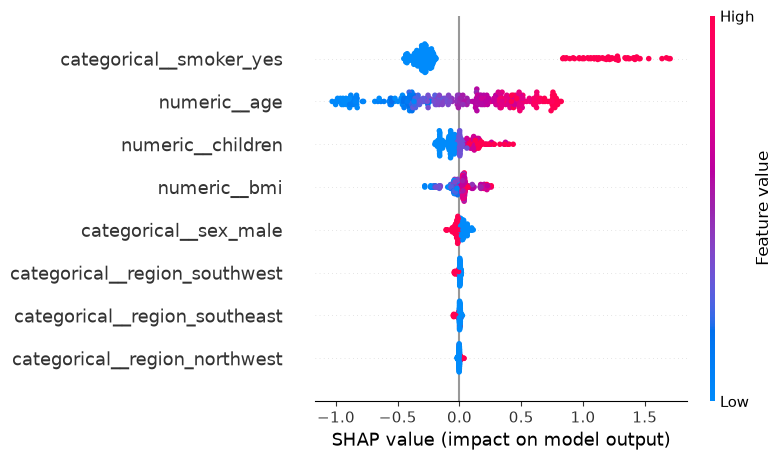

In [54]:
# 1. Each model needs SHAP set up differently
if WINNER_NAME == "CatBoost":
    # CatBoost needs its data wrapped in a Pool so that SHAP knows which columns are categorical
    shap_frame = X_test
    shap_values = shap.TreeExplainer(winning_model).shap_values(
        cb.Pool(X_test, y_test_model, cat_features=CATEGORICAL_FEATURES)
    )
elif WINNER_NAME == "Random Forest":
    # 1.1 Everything except the final estimator is the encoder, so slicing gives the
    #     exact matrix the forest was grown on
    shap_frame = pd.DataFrame(winning_model[:-1].transform(X_test), columns=random_forest_terms)
    shap_values = shap.TreeExplainer(winning_model.named_steps["model"]).shap_values(shap_frame)
elif WINNER_NAME == "Linear Regression":
    # 1.2 A linear model has no trees to walk, so SHAP reads its coefficients instead
    shap_frame = pd.DataFrame(winning_model[:-1].transform(X_test), columns=linear_terms)
    shap_values = shap.LinearExplainer(
        winning_model.named_steps["model"], shap_frame
    ).shap_values(shap_frame)
else:
    shap_frame = X_test
    shap_values = shap.TreeExplainer(winning_model).shap_values(shap_frame)

# 2. Show the contribution of every feature, one test row at a time
print(f"SHAP values: {np.asarray(shap_values).shape} (test rows x features)")

shap.summary_plot(shap_values, shap_frame)

## 4.16 Save and Load the Winning Model

The pickle holds more than the model. A model trained on `log1p(charges)` returns log dollars, and
anything that loads it without knowing that would be wrong by a factor of thousands. The target
treatment therefore travels **with** the model, along with the column order and the categorical
column names needed to rebuild an input frame.

The reload step re-predicts and asserts the output is identical. That is the point of the
reference notebook's load section, without re-printing every metric a second time.

In [55]:
# 1. Save the model together with everything needed to use it correctly
# 1.1 "Random Forest" has a space in it, which does not belong in a filename
model_slug = WINNER_NAME.lower().replace(" ", "_")
model_path = MODEL_DIR / f"{model_slug}_insurance_model.pkl"
artefact = {
    "model": winning_model,
    "model_name": WINNER_NAME,
    "use_log_target": USE_LOG_TARGET,
    "target": TARGET,
    "feature_order": X_train.columns.tolist(),
    "categorical_features": CATEGORICAL_FEATURES,
}
joblib.dump(artefact, model_path)
print(f"Saved {model_path.name} ({model_path.stat().st_size / 1024:,.0f} KB)")

# 2. Load it back and prove the round trip changed nothing
loaded = joblib.load(model_path)
reloaded_prediction = loaded["model"].predict(X_test)

assert loaded["use_log_target"] == USE_LOG_TARGET
assert loaded["feature_order"] == X_train.columns.tolist()
assert np.allclose(reloaded_prediction, winning_model.predict(X_test))
print("Reloaded model predicts identically, and carries its target treatment.")

# 3. Show how a consumer turns a raw prediction back into dollars
sample = to_dollar_space(reloaded_prediction[:5])
print(f"\nFirst five reloaded predictions, in dollars: {np.round(sample, 2).tolist()}")
print(f"Actual charges for the same rows           : {y_test.head().round(2).tolist()}")

Saved random_forest_insurance_model.pkl (2,647 KB)
Reloaded model predicts identically, and carries its target treatment.

First five reloaded predictions, in dollars: [9867.54, 5668.78, 11895.17, 39291.31, 5035.61]
Actual charges for the same rows           : [8688.86, 5708.87, 11436.74, 38746.36, 4463.21]


## 4.17 What Notebook 03 Produced

- A target-treatment decision, measured rather than assumed, in 4.3.
- Five tuned regressors from three families - three gradient-boosting libraries, one bagged
  forest and one linear equation - each cross-validated before and after tuning.
- One comparison table on held-out data, and a named winner, with a linear baseline in it so
  that the winner's score can be read as a gain rather than as a bare number.
- A SHAP explanation of that winner.
- `models/<winner>_insurance_model.pkl`, holding the model **and** the target treatment it needs.

Anything that consumes the saved artefact must apply `expm1` to the raw prediction when
`use_log_target` is `True`. That flag is stored in the pickle precisely so a consumer never has to
guess.